# Rhythms of the Sleeping Brain
## ARIMA Modeling & Spectral Analysis of EEG Alpha Power Across Human Sleep Cycles

**Author:** Clark Enge (clarkenge@ucsb.edu)

**Course:** PSTAT W 274 — Time Series Analysis

**Data:** PhysioNet Sleep-EDF Expanded Database (Kemp et al., 2000) — recording `SC4001E0-PSG.edf`, channel `EEG Fpz-Cz`

---

### What I set out to do

I take a full overnight EEG recording and reduce it to one number per 30-second epoch: the power in the
**alpha band (8–13 Hz)**. That gives me a univariate series of ~2650 points spanning ~22 hours, which I model
as a time series. Alpha power is a reasonable proxy for arousal state — high near sleep onset and in REM,
suppressed in deep slow-wave sleep — so a model of its trajectory is a small step toward a sleep-state predictor
for closed-loop neural devices.

Everything below is done by hand: I identify orders from the ACF/PACF, program AICc myself, and never call
`auto_arima` or `checkresiduals`. The interesting twist is that the physiologically "obvious" seasonal model
turns out to be wrong, and I document why I abandoned it.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal
from scipy.stats import probplot, shapiro, kstest
from scipy.special import comb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings, os

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})

EDF_FILE   = 'data/SC4001E0-PSG.edf'
EPOCH_SEC  = 30        # standard PSG scoring epoch (s)
ALPHA_LO   = 8.0       # alpha band lower edge (Hz)
ALPHA_HI   = 13.0      # alpha band upper edge (Hz)
FS         = 100       # recording sample rate (Hz)
TRAIN_FRAC = 0.80
# ~90-min NREM-REM cycle = 180 epochs. I keep this only as a label for the spectral
# plots; Section 6 shows it does NOT work as a SARIMA seasonal period.
S_ULTRADIAN = 180

FIGURES_DIR = 'outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Data Loading

The recording is in European Data Format (EDF), the standard for polysomnography. I read it with `mne` and keep
the `EEG Fpz-Cz` channel (frontal midline), which is a good site for sleep-related alpha activity. The recording
is already at 100 Hz so no resampling is needed.

In [2]:
def load_edf_channel(edf_path, channel='EEG Fpz-Cz'):
    """Load one EEG channel from an EDF file. Returns (signal, sfreq)."""
    import mne
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick(channel)                       
    if raw.info['sfreq'] != FS:
        raw.resample(FS, npad='auto')
    data, _ = raw[:]
    return data.squeeze(), raw.info['sfreq']

raw_eeg, sfreq = load_edf_channel(EDF_FILE)
print(f'Signal shape : {raw_eeg.shape}')
print(f'Sampling rate: {sfreq} Hz')
print(f'Duration     : {len(raw_eeg)/sfreq/3600:.2f} hours')

Signal shape : (7950000,)
Sampling rate: 100.0 Hz
Duration     : 22.08 hours


## 3. Alpha Power Extraction

For each 30-second epoch I compute a single scalar (alpha-band power) in three steps:

1. **Band-pass filter** the epoch to [8, 13] Hz with a 4th-order zero-phase Butterworth filter (`sosfiltfilt`).
   Zero-phase matters on short segments: a causal filter adds a phase lag that would distort the power estimate.
2. **Welch PSD** with 2-second Hann windows and 50% overlap, which trades a little frequency resolution for a
   much lower-variance spectral estimate than the raw periodogram.
3. **Integrate** the PSD across the alpha band:
$$X_t = \int_{8}^{13} \hat{P}_{xx}(f)\,df \approx \sum_{f_k\in[8,13]} \hat{P}_{xx}(f_k)\,\Delta f$$

The result is a ~2650-point series in units of $\mu V^2/\text{Hz}$.

In [3]:
def bandpass_filter(signal_arr, lo, hi, fs, order=4):
    """Zero-phase Butterworth band-pass via second-order sections."""
    nyq = 0.5 * fs
    sos = signal.butter(order, [lo/nyq, hi/nyq], btype='band', output='sos')
    return signal.sosfiltfilt(sos, signal_arr)

def compute_epoch_alpha_power(raw_signal, fs, epoch_sec=EPOCH_SEC, lo=ALPHA_LO, hi=ALPHA_HI):
    """Build the univariate alpha-power series X_t, one value per epoch."""
    N_ep = int(fs * epoch_sec)
    n_epochs = len(raw_signal) // N_ep
    alpha_power = np.empty(n_epochs)
    for t in range(n_epochs):
        seg = raw_signal[t*N_ep:(t+1)*N_ep]
        filt = bandpass_filter(seg, lo, hi, fs)
        freqs, pxx = signal.welch(filt, fs=fs, nperseg=int(fs*2), window='hann', scaling='density')
        mask = (freqs >= lo) & (freqs <= hi)
        alpha_power[t] = np.trapezoid(pxx[mask], freqs[mask])   # np.trapz renamed in NumPy 2.x
    return alpha_power

X_raw = compute_epoch_alpha_power(raw_eeg, sfreq)
X_t = pd.Series(X_raw, name='alpha_power_uV2')
print(f'Series length : {len(X_t)} epochs  (~{len(X_t)*EPOCH_SEC/3600:.1f} hours)')
print(f'Value range   : [{X_t.min():.3e}, {X_t.max():.3e}] uV^2/Hz')
print(f'Mean          : {X_t.mean():.3e}   Skewness: {X_t.skew():.3f}')

Series length : 2650 epochs  (~22.1 hours)
Value range   : [1.903e-12, 2.474e-11] uV^2/Hz
Mean          : 7.156e-12   Skewness: 0.000


## 4. Train / Test Split

I hold out the last 20% of epochs as a contiguous test block at the end of the night (never shuffled, that would
leak future information). All identification and fitting use the training set only; the test set is touched once,
for validation. One caveat I am aware of: sleep architecture shifts across the night (more REM/light sleep later),
so a tail-end test set is a slightly harder target than a random window would be. However, with 22.1 hours of sleep, this is most likely neglibile.

In [4]:
split_idx = int(len(X_t) * TRAIN_FRAC)
train = X_t.iloc[:split_idx].copy()
test  = X_t.iloc[split_idx:].copy()
print(f'Train: {len(train)} epochs ({len(train)*EPOCH_SEC/3600:.1f} hr)')
print(f'Test : {len(test)}  epochs ({len(test)*EPOCH_SEC/3600:.1f} hr)')

Train: 2120 epochs (17.7 hr)
Test : 530  epochs (4.4 hr)


## 5. Exploratory Data Analysis

Before fitting anything I look at the training series three ways: the raw trace, rolling mean/standard deviation
(window = 6 epochs = 3 min), and the marginal histogram. I am checking for trend, for whether the spread grows
with the level (which would call for a log transform), and for skew.

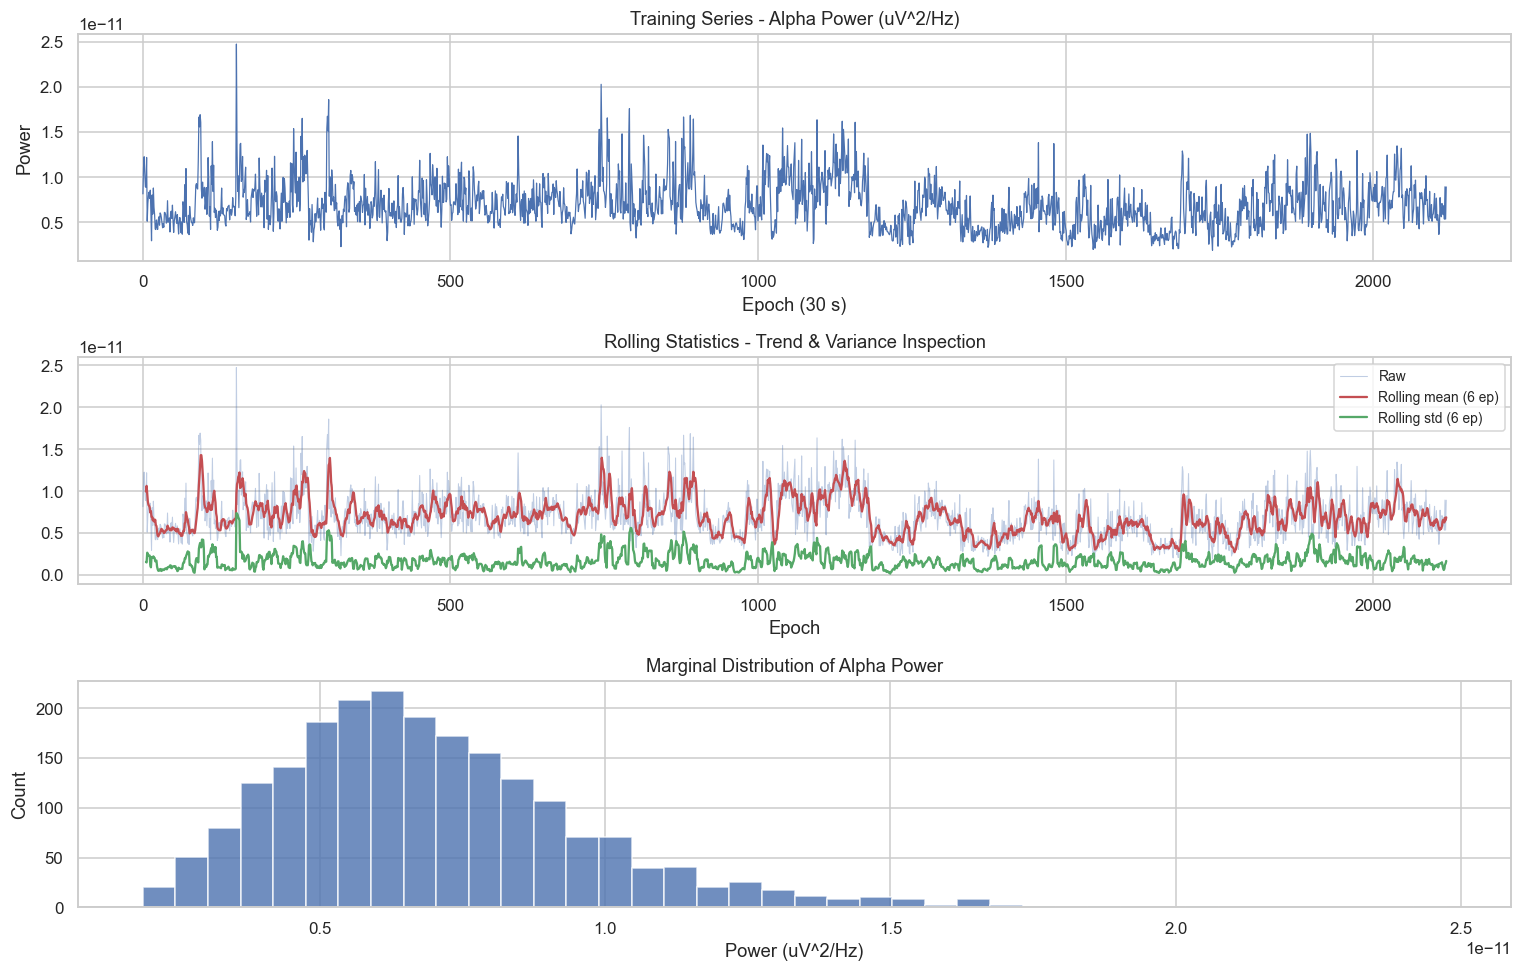

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(train.values, color='#4C72B0', lw=0.8)
axes[0].set_title('Training Series - Alpha Power (uV^2/Hz)')
axes[0].set_xlabel('Epoch (30 s)'); axes[0].set_ylabel('Power')

roll = train.rolling(window=6)
axes[1].plot(train.values, alpha=0.35, color='#4C72B0', lw=0.7, label='Raw')
axes[1].plot(roll.mean().values, color='#C44E52', lw=1.5, label='Rolling mean (6 ep)')
axes[1].plot(roll.std().values,  color='#55A868', lw=1.5, label='Rolling std (6 ep)')
axes[1].set_title('Rolling Statistics - Trend & Variance Inspection')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=9)

axes[2].hist(train.dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[2].set_title('Marginal Distribution of Alpha Power')
axes[2].set_xlabel('Power (uV^2/Hz)'); axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/eda_plots.png', bbox_inches='tight')
plt.show()

**What I see:** The rolling standard deviation rises and falls together with the rolling mean, meaning the spread is
proportional to the level. That is the textbook signature of a multiplicative process, so a log transform should
stabilise the variance. The histogram is right-skewed, which points the same way. There is no strong monotone
trend, but the mean clearly wanders, so the series is currently not stationary.

## 6. Stationarity, Transformation, and the Seasonal Question

### 6.1 Log transform and ADF

I apply $Y_t = \log(X_t + \varepsilon)$ with $\varepsilon = 10^{-6}\cdot\text{median}(X_t)$ to guard against
$\log 0$, then test stationarity with the Augmented Dickey-Fuller test.

**Important caveat about ADF.** ADF only tests for a *unit root in the AR part* (i.e. a stochastic trend). It says
nothing about seasonality, changing variance, or structural breaks. A series can "pass" ADF and still be
non-stationary in other ways, so I treat it as one piece of evidence, read alongside the EDA and the ACF.

In [6]:
def log_transform(series):
    eps = 1e-6 * series.median()
    return np.log(series + eps)

def manual_difference(series, d=1, D=0, S=0):
    """(1-B)^d then (1-B^S)^D, applied in sequence."""
    out = series.copy()
    for _ in range(d):
        out = out.diff(1).dropna()
    if D > 0 and S > 0:
        for _ in range(D):
            out = out.diff(S).dropna()
    return out

def run_adf_test(series, label=''):
    r = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF [{label}]: stat={r[0]:+.4f}  p={r[1]:.4g}  lags={r[2]}  '
          f'crit5%={r[4]["5%"]:.3f}  -> {"STATIONARY" if r[1]<0.05 else "NON-STATIONARY"}')
    return {'label': label, 'stat': r[0], 'pval': r[1]}

eps_val = 1e-6 * X_t.median()
Y_t = log_transform(train)
W_t = manual_difference(Y_t, d=1)

adf_log  = run_adf_test(Y_t, 'log(X_t)')
adf_diff = run_adf_test(W_t, 'd1 log(X_t)')

ADF [log(X_t)]: stat=-7.6927  p=1.406e-11  lags=8  crit5%=-2.863  -> STATIONARY
ADF [d1 log(X_t)]: stat=-16.9189  p=9.976e-30  lags=15  crit5%=-2.863  -> STATIONARY


`log(X_t)` already rejects the ADF null (stat $\approx -7.69$, $p\approx 10^{-11}$), so there is no unit root in
the *log level*. But the rolling mean in the EDA is visibly non-constant, and (as the ACF below shows) the log
level decays slowly — both signs that I still want one regular difference for practical ARMA modeling. This is
exactly the situation the ADF caveat warns about: passing ADF is not the same as being stationary. After one
difference, $\nabla\log(X_t)$ is comfortably stationary (stat $\approx -16.9$).

### 6.2 Testing the seasonal heuristic (S = 18 and S = 180)

The physiology suggests an obvious seasonal model: the NREM-REM cycle is ~90 minutes = 180 epochs (or ~9 min = 18
epochs for spindle cadence). The natural move is a seasonal SARIMA with $S = 180$. I tested that idea and decided
**against** it, on three independent grounds, which I show below.

In [7]:
# (1) Over-differencing check: a *correct* seasonal difference should REDUCE variance.
print('Variance by differencing stage:')
print(f'  log(X_t)            : {Y_t.var():.5f}')
print(f'  d1 log(X_t)         : {W_t.var():.5f}')
for S in (18, S_ULTRADIAN):
    v = manual_difference(Y_t, d=1, D=1, S=S).var()
    print(f'  d1 + D1_S{S:<3} log(X_t): {v:.5f}   '
          f'({"INCREASED -> over-differencing" if v > W_t.var() else "reduced -> ok"})')

# (2) Is there any seasonal autocorrelation to model?
Wd = W_t.dropna(); ci = 1.96/np.sqrt(len(Wd))
a200 = acf(Wd, nlags=200); p200 = pacf(Wd, nlags=200, method='ywm')
print(f'\nSeasonal-lag ACF/PACF (95% band = +-{ci:.3f}):')
for k in (18, 147, 180, 189):
    print(f'  lag {k:>3}: ACF={a200[k]:+.3f}  PACF={p200[k]:+.3f}')

Variance by differencing stage:
  log(X_t)            : 0.14412
  d1 log(X_t)         : 0.11139
  d1 + D1_S18  log(X_t): 0.22983   (INCREASED -> over-differencing)
  d1 + D1_S180 log(X_t): 0.21987   (INCREASED -> over-differencing)

Seasonal-lag ACF/PACF (95% band = +-0.043):
  lag  18: ACF=-0.033  PACF=-0.029
  lag 147: ACF=+0.009  PACF=-0.011
  lag 180: ACF=+0.025  PACF=+0.019
  lag 189: ACF=-0.005  PACF=-0.011


**Why I dropped the seasonal term.**

1. **Over-differencing.** A genuine seasonal difference should *shrink* the variance. Instead, seasonal
   differencing *increases* it at both periods (0.111 → 0.230 at $S=18$, → 0.220 at $S=180$). That is the classic
   over-differencing signature — the seasonal difference is injecting variance, not removing it.
2. **No seasonal signature.** The ACF and PACF of $\nabla\log(X_t)$ have no significant spike at lag 18, 147, 180,
   or 189 — every value sits inside the $\pm 1.96/\sqrt{n}$ band. There is simply no seasonal autocorrelation to
   model, because the ultradian rhythm is *spectrally broad* (the periodogram in Section 11 spreads its sleep-cycle
   energy across 66–95 min) rather than locked to one sharp lag.
3. **Infeasibility.** A state-space SARIMA at $S=180$ carries a ~180-dimensional state and did not converge in any
   reasonable time on this series — with only ~14 cycles in the record there is little to gain anyway.

So I model the mean with a **non-seasonal ARIMA** and treat the 90-minute rhythm as a *spectral* finding in
Section 11, not a differencing operation. This is the key modeling decision of the project.

## 7. ACF & PACF — Model Identification

With $d = 1$ settled and no seasonal term, I identify the non-seasonal orders from the ACF/PACF of
$\nabla\log(X_t)$. My reading rules: ACF cuts off at $q$ with a tailing PACF $\Rightarrow$ MA($q$); PACF cuts off
at $p$ with a tailing ACF $\Rightarrow$ AR($p$); both tail off $\Rightarrow$ mixed ARMA($p,q$).

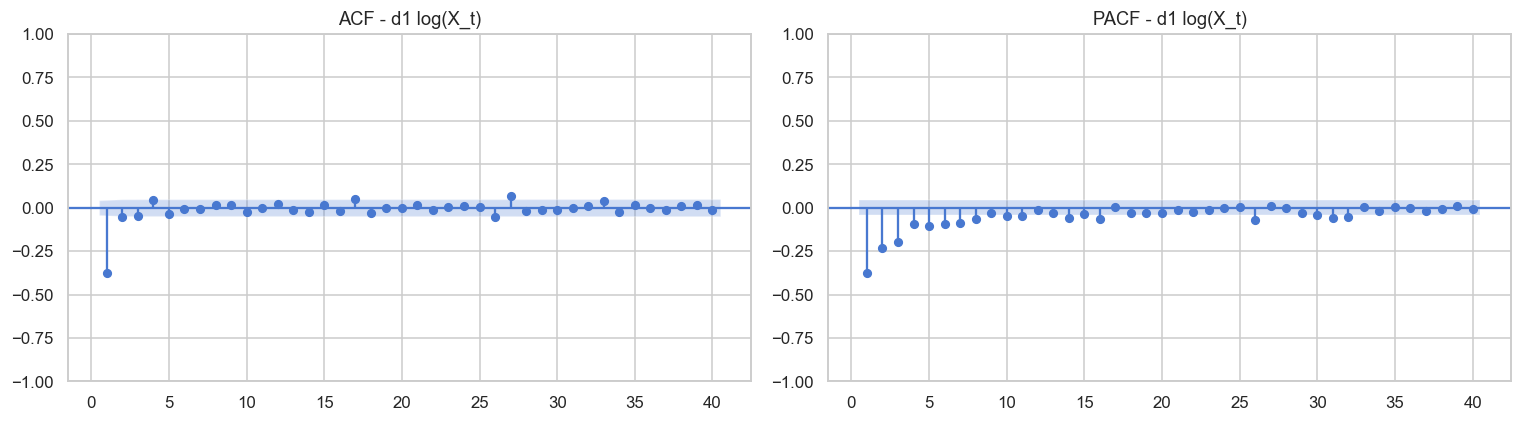

lag  ACF     PACF
  1  -0.378  -0.378
  2  -0.057  -0.233
  3  -0.048  -0.200
  4  +0.044  -0.096
  5  -0.036  -0.104


In [8]:
def plot_acf_pacf(series, lags=40, title='', fname='acf_pacf.png'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series.dropna(),  lags=lags, alpha=0.05, ax=ax1, title=f'ACF - {title}', zero=False)
    plot_pacf(series.dropna(), lags=lags, alpha=0.05, ax=ax2, title=f'PACF - {title}', zero=False, method='ywm')
    plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/{fname}', bbox_inches='tight'); plt.show()

plot_acf_pacf(W_t, lags=40, title='d1 log(X_t)', fname='acf_pacf.png')

# numeric read of the first few lags
a = acf(W_t.dropna(), nlags=6); p = pacf(W_t.dropna(), nlags=6, method='ywm')
print('lag  ACF     PACF')
for k in range(1, 6):
    print(f'{k:3d}  {a[k]:+.3f}  {p[k]:+.3f}')

**First guess: MA(1), i.e. ARIMA(0,1,1).** The ACF has one big negative spike at lag 1 ($\approx -0.38$) and then
collapses into the band, while the PACF decays gradually across several lags. That is the canonical MA(1) pattern.
I will carry ARIMA(0,1,1) as my ACF/PACF candidate and check whether AICc and the residual diagnostics agree.

## 8. Model Fitting & AICc Comparison

I fit non-seasonal $\text{ARIMA}(p,1,q)$ models on the log series, comparing them with a hand-coded AICc:
$$\text{AICc} = -2\,\ell(\hat\theta) + 2k + \frac{2k(k+1)}{n-k-1}$$
where $k$ counts the free parameters including $\sigma^2$. I sweep a small, deliberately chosen set around my
ACF/PACF guess rather than an automated grid.

In [9]:
def compute_aicc(ll, k, n):
    if n - k - 1 <= 0:
        raise ValueError('overparameterised')
    return -2*ll + 2*k + 2*k*(k+1)/(n-k-1)

def fit_arima(endog, order, label):
    m = SARIMAX(endog, order=order, seasonal_order=(0,0,0,0), trend='n',
                enforce_stationarity=True, enforce_invertibility=True).fit(disp=False, maxiter=200)
    k, n = m.df_model + 1, m.nobs
    aicc = compute_aicc(m.llf, k, n)
    print(f'  {label:<13} ll={m.llf:8.2f}  AIC={m.aic:8.2f}  AICc={aicc:8.2f}  BIC={m.bic:8.2f}  k={k}')
    return {'label': label, 'result': m, 'aicc': aicc, 'order': order}

candidates = {'ARIMA(0,1,1)':(0,1,1), 'ARIMA(1,1,1)':(1,1,1), 'ARIMA(2,1,1)':(2,1,1),
              'ARIMA(1,1,2)':(1,1,2), 'ARIMA(2,1,2)':(2,1,2)}
fits = {nm: fit_arima(Y_t, o, nm) for nm, o in candidates.items()}
best = min(fits.values(), key=lambda d: d['aicc'])
print(f'\nBest by AICc: {best["label"]}  (AICc = {best["aicc"]:.2f})')

res = best['result']
print(f'\n{best["label"]} coefficients:')
for nm, v, se in zip(res.param_names, res.params, res.bse):
    print(f'  {nm:<10} = {v:+.5f}  (SE={se:.5f})')

  ARIMA(0,1,1)  ll= -393.69  AIC=  791.37  AICc=  793.38  BIC=  802.69  k=3
  ARIMA(1,1,1)  ll= -362.29  AIC=  730.57  AICc=  732.59  BIC=  747.55  k=4
  ARIMA(2,1,1)  ll= -357.88  AIC=  723.76  AICc=  725.79  BIC=  746.39  k=5
  ARIMA(1,1,2)  ll= -354.60  AIC=  717.20  AICc=  719.23  BIC=  739.84  k=5
  ARIMA(2,1,2)  ll= -344.42  AIC=  698.85  AICc=  700.89  BIC=  727.14  k=6

Best by AICc: ARIMA(2,1,2)  (AICc = 700.89)

ARIMA(2,1,2) coefficients:
  ar.L1      = +1.13399  (SE=0.04370)
  ar.L2      = -0.18727  (SE=0.03381)
  ma.L1      = -1.72957  (SE=0.03648)
  ma.L2      = +0.73112  (SE=0.03595)
  sigma2     = +0.08096  (SE=0.00217)


**Model selection.** 

AICc drops steadily as I enrich the model: 793.4 (0,1,1) → 725.8 (2,1,1) → 719.2 (1,1,2)
→ **700.9 (2,1,2)**. ARIMA(2,1,2) wins decisively (next-best is ~18 AICc units away; anything past 10 is decisive).

**Is the AICc model the same as the ACF/PACF model?** 

No. My ACF/PACF reading
suggested MA(1) = ARIMA(0,1,1), but that model fails the residual tests below (its Ljung-Box is rejected at every
lag). The ACF/PACF gave the right starting point, but residual diagnostics and AICc together pushed me to the
richer ARIMA(2,1,2). I read this as the simple MA(1) capturing the dominant lag-1 structure while leaving slower
dynamics that the AR terms then absorb.

**Fitted model (log scale, $Y_t = \log(X_t+\varepsilon)$).**

 With $\hat\phi_1=1.134,\ \hat\phi_2=-0.187,\
\hat\theta_1=-1.730,\ \hat\theta_2=0.731,\ \hat\sigma^2=0.081$:
$$(1 - 1.134\,B + 0.187\,B^2)(1-B)\,Y_t = (1 - 1.730\,B + 0.731\,B^2)\,\varepsilon_t,\qquad \varepsilon_t\sim WN(0,\,0.081)$$

## 9. Residual Diagnostics

A good model leaves residuals that look like white noise. I check four ways: a Ljung-Box test on the residuals,
a Shapiro-Wilk normality test, the **McLeod-Li test** (Ljung-Box on the *squared* residuals, which catches
nonlinear / ARCH structure that the ordinary Ljung-Box cannot), and visual checks (residual trace, residual ACF,
Q-Q plot).

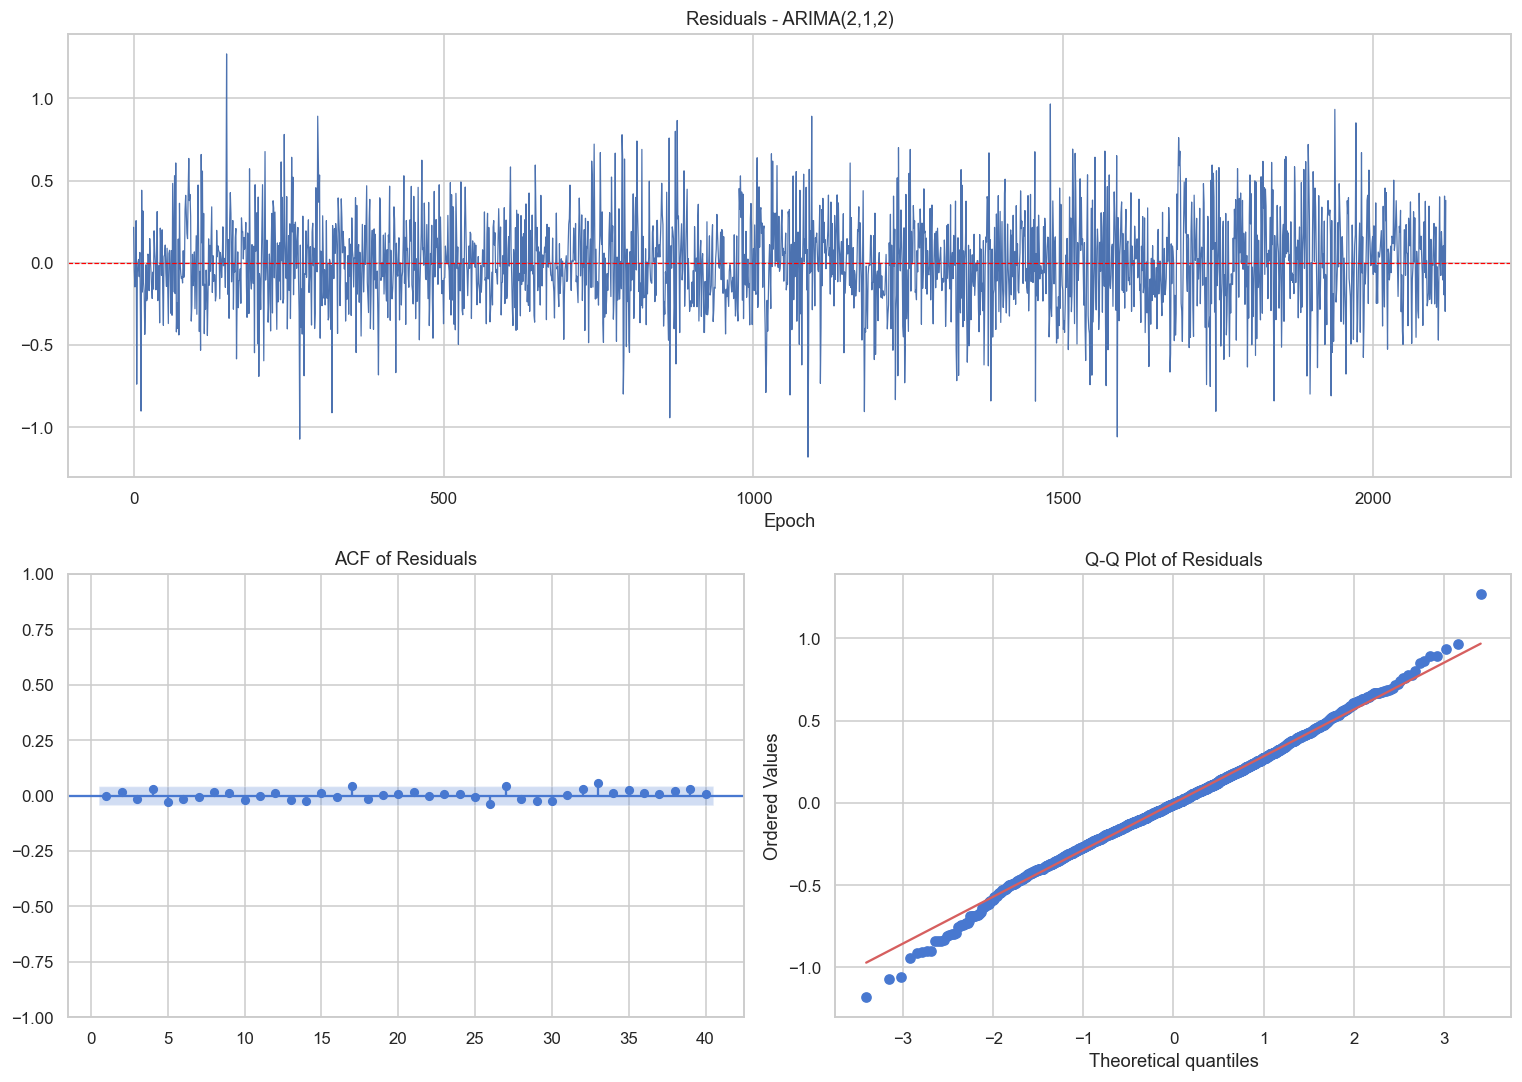

Ljung-Box (residuals, ARIMA(2,1,2)):
      lb_stat  lb_pvalue
10   7.207771   0.705695
20  14.277459   0.816154
30  25.630602   0.693845

Shapiro-Wilk (first 500): W=0.9882  p=4.52e-04

McLeod-Li (Ljung-Box on squared residuals):
      lb_stat     lb_pvalue
10  57.454537  1.094938e-08
20  69.831638  1.940330e-07
30  79.091712  2.666469e-06


In [10]:
def mcleod_li_test(resid, lags=(10,20,30)):
    """McLeod-Li = Ljung-Box on squared residuals. Detects ARCH / nonlinear structure."""
    lb = acorr_ljungbox(pd.Series(resid**2), lags=list(lags), return_df=True)
    print('McLeod-Li (Ljung-Box on squared residuals):'); print(lb.to_string()); return lb

def residual_diagnostics(fit_result, label='', fname_prefix=''):
    resid = fit_result.resid.dropna().values[2:]   # drop diffuse state-space init transient
    fig = plt.figure(figsize=(14, 10)); gs = gridspec.GridSpec(2, 2, figure=fig)
    ax1 = fig.add_subplot(gs[0, :]); ax1.plot(resid, color='#4C72B0', lw=0.8)
    ax1.axhline(0, color='red', lw=0.8, ls='--'); ax1.set_title(f'Residuals - {label}'); ax1.set_xlabel('Epoch')
    ax2 = fig.add_subplot(gs[1, 0]); plot_acf(resid, lags=40, alpha=0.05, ax=ax2, zero=False, title='ACF of Residuals')
    ax3 = fig.add_subplot(gs[1, 1]); probplot(resid, dist='norm', plot=ax3); ax3.set_title('Q-Q Plot of Residuals')
    plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/residuals_{fname_prefix}.png', bbox_inches='tight'); plt.show()
    print(f'Ljung-Box (residuals, {label}):')
    print(acorr_ljungbox(resid, lags=[10,20,30], return_df=True).to_string())
    sw = shapiro(resid[:500]); print(f'\nShapiro-Wilk (first 500): W={sw[0]:.4f}  p={sw[1]:.2e}\n')
    mcleod_li_test(resid, lags=(10,20,30))
    return resid

resid = residual_diagnostics(res, label=best['label'], fname_prefix='ARIMA212')

**Reading the diagnostics.**

- **Ljung-Box on the residuals passes** at every lag ($p \approx 0.71,\,0.82,\,0.69$ at lags 10/20/30). The linear
  autocorrelation structure is fully captured — the residual ACF sits inside the bands.
- **Shapiro-Wilk** gives $W = 0.988$ ($p \approx 5\times10^{-4}$). With $n=2118$ the test is extremely sensitive, so
  it rejects strict normality, but $W$ this close to 1 plus a near-straight Q-Q plot means the departures are mild
  (slightly heavy tails, expected for EEG power). I do not treat this as fatal.
- **McLeod-Li fails** hard ($p \sim 10^{-8}$). The *squared* residuals are autocorrelated even though the residuals
  themselves are not — i.e. there is volatility clustering / conditional heteroscedasticity (an ARCH effect). The
  mean model is adequate, but the variance is not constant. This is a real, expected feature of EEG power and is
  the cleanest motivation for a future ARIMA+GARCH extension.

## 10. Forecasting & Back-Transformation

I forecast on the log scale and invert with a log-normal bias correction. Because $Y_t=\log(X_t+\varepsilon)$ is
Gaussian, $E[e^Y]=e^{\mu+\sigma^2/2}$, so the bias-corrected point forecast is
$\hat X_{n+h}=\exp(\hat Y_{n+h}+\hat\sigma_h^2/2)-\varepsilon$; dropping the $\sigma_h^2/2$ term would
systematically under-predict.

A 530-step *static* forecast is meaningless here. An ARIMA forecast reverts to a constant within a few dozen steps,
so the number I actually report is the **1-step-ahead** forecast: I freeze the fitted parameters and filter through
the test set (`append(..., refit=False)`), predicting each epoch from the real past. I also compare against two
naive baselines so the model has to earn its keep.

Forecast accuracy on the test set:
  ARIMA(2,1,2) 1-step      MAE=1.532e-12  RMSE=2.020e-12  MAPE=20.09%
  persistence (lag 1)      MAE=1.810e-12  RMSE=2.433e-12  MAPE=23.24%
  naive seasonal (S=180)   MAE=2.368e-12  RMSE=3.041e-12  MAPE=31.19%


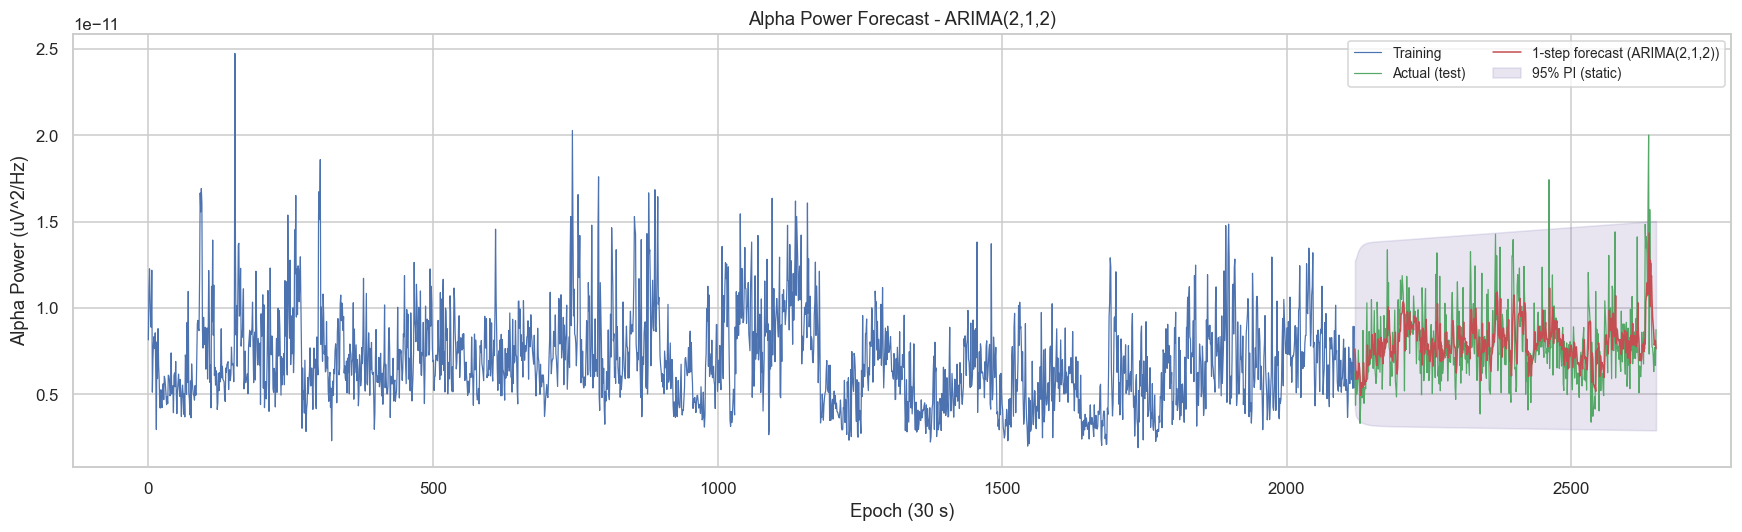

In [11]:
def backtransform_mean(mean, var, eps): return np.exp(mean + var/2.0) - eps

# genuine 1-step-ahead over the test window with fixed parameters
y_test_log = np.log(test + eps_val)
appended   = res.append(y_test_log, refit=False)
pred_log   = appended.predict(start=split_idx, end=len(X_t)-1)
pred_1step = backtransform_mean(pred_log.values, res.params[-1], eps_val)
actual     = test.values

def report(name, pred):
    mae = np.mean(np.abs(actual-pred)); rmse = np.sqrt(np.mean((actual-pred)**2))
    mape = np.mean(np.abs((actual-pred)/actual))*100
    print(f'  {name:<24} MAE={mae:.3e}  RMSE={rmse:.3e}  MAPE={mape:.2f}%')

print('Forecast accuracy on the test set:')
report(f'{best["label"]} 1-step', pred_1step)
report('persistence (lag 1)', X_t.shift(1).iloc[split_idx:].values)
report('naive seasonal (S=180)', X_t.shift(S_ULTRADIAN).iloc[split_idx:].values)

# static multi-step forecast (only for the CI band on the plot)
fc = res.get_forecast(steps=len(test)); ci = fc.conf_int(alpha=0.05).values
lo = np.exp(ci[:,0]) - eps_val; hi = np.exp(ci[:,1]) - eps_val

fig, ax = plt.subplots(figsize=(16, 5))
t_tr = np.arange(len(train)); t_te = np.arange(len(train), len(train)+len(test))
ax.plot(t_tr, train.values, color='#4C72B0', lw=0.8, label='Training')
ax.plot(t_te, actual,      color='#55A868', lw=0.8, label='Actual (test)')
ax.plot(t_te, pred_1step,  color='#C44E52', lw=1.0, label=f'1-step forecast ({best["label"]})')
ax.fill_between(t_te, lo, hi, color='#8172B3', alpha=0.18, label='95% PI (static)')
ax.set_title(f'Alpha Power Forecast - {best["label"]}')
ax.set_xlabel('Epoch (30 s)'); ax.set_ylabel('Alpha Power (uV^2/Hz)'); ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/forecast.png', bbox_inches='tight'); plt.show()

**Forecast result.** The 1-step-ahead MAPE is **20.1%**, versus 23.2% for persistence and 31.2% for the naive
seasonal baseline. The model beats both, so it is adding genuine short-horizon information beyond "tomorrow looks
like today" and beyond "repeat the last sleep cycle". A ~20% error at 30-second resolution is respectable for a
fully transparent linear model on a noisy biosignal, though the McLeod-Li result tells me the prediction
*intervals* are the weak point — constant-variance intervals will be too wide in calm stretches and too narrow
during volatile transitions.

## 11. Spectral Analysis (PSTAT 274)

I use spectral tools two ways: the **periodogram to locate seasonality** in the
series, and **Fisher's g-test and the Kolmogorov-Smirnov cumulative-periodogram test on the residuals** to confirm
they are white noise. 

(Neither test ships as a one-liner in SciPy/statsmodels, so I implemented both from their
definitions; the R equivalents are `GeneCycle::fisher.g.test` and `stats::cpgram`.)

In [12]:
def fisher_g_test(Pxx):
    """g = max(I)/sum(I); exact p = sum_k (-1)^{k-1} C(m,k) (1-kg)^{m-1}. H0: white noise."""
    m = len(Pxx); g = float(np.max(Pxx)/np.sum(Pxx)); up = int(np.floor(1/g))
    pv = sum((-1)**(k-1)*float(comb(m,k,exact=True))*(1-k*g)**(m-1) for k in range(1, up+1))
    return g, float(np.clip(pv, 0, 1))

def ks_cumulative_periodogram(Pxx):
    """Bartlett KS: under white noise the normalised cumulative periodogram ~ Uniform(0,1)."""
    cum = np.cumsum(Pxx)/np.sum(Pxx)
    d, p = kstest(cum[:-1], 'uniform')   # drop terminal 1.0
    return float(d), float(p), cum

Series periodogram  : Fisher g=0.07843  p=1.43e-44
Top periodogram peaks:
   0.045 cyc/hr  ~  1325.0 min
   0.091 cyc/hr  ~   662.5 min
   0.815 cyc/hr  ~    73.6 min
   0.634 cyc/hr  ~    94.6 min
   0.906 cyc/hr  ~    66.2 min
   0.860 cyc/hr  ~    69.7 min

Residual Fisher g-test: g=0.00782  p=0.233  -> no leftover periodicity
Residual KS test      : D=0.0183  p=0.865  -> consistent with white noise

Parametric AR order (AIC) = 17


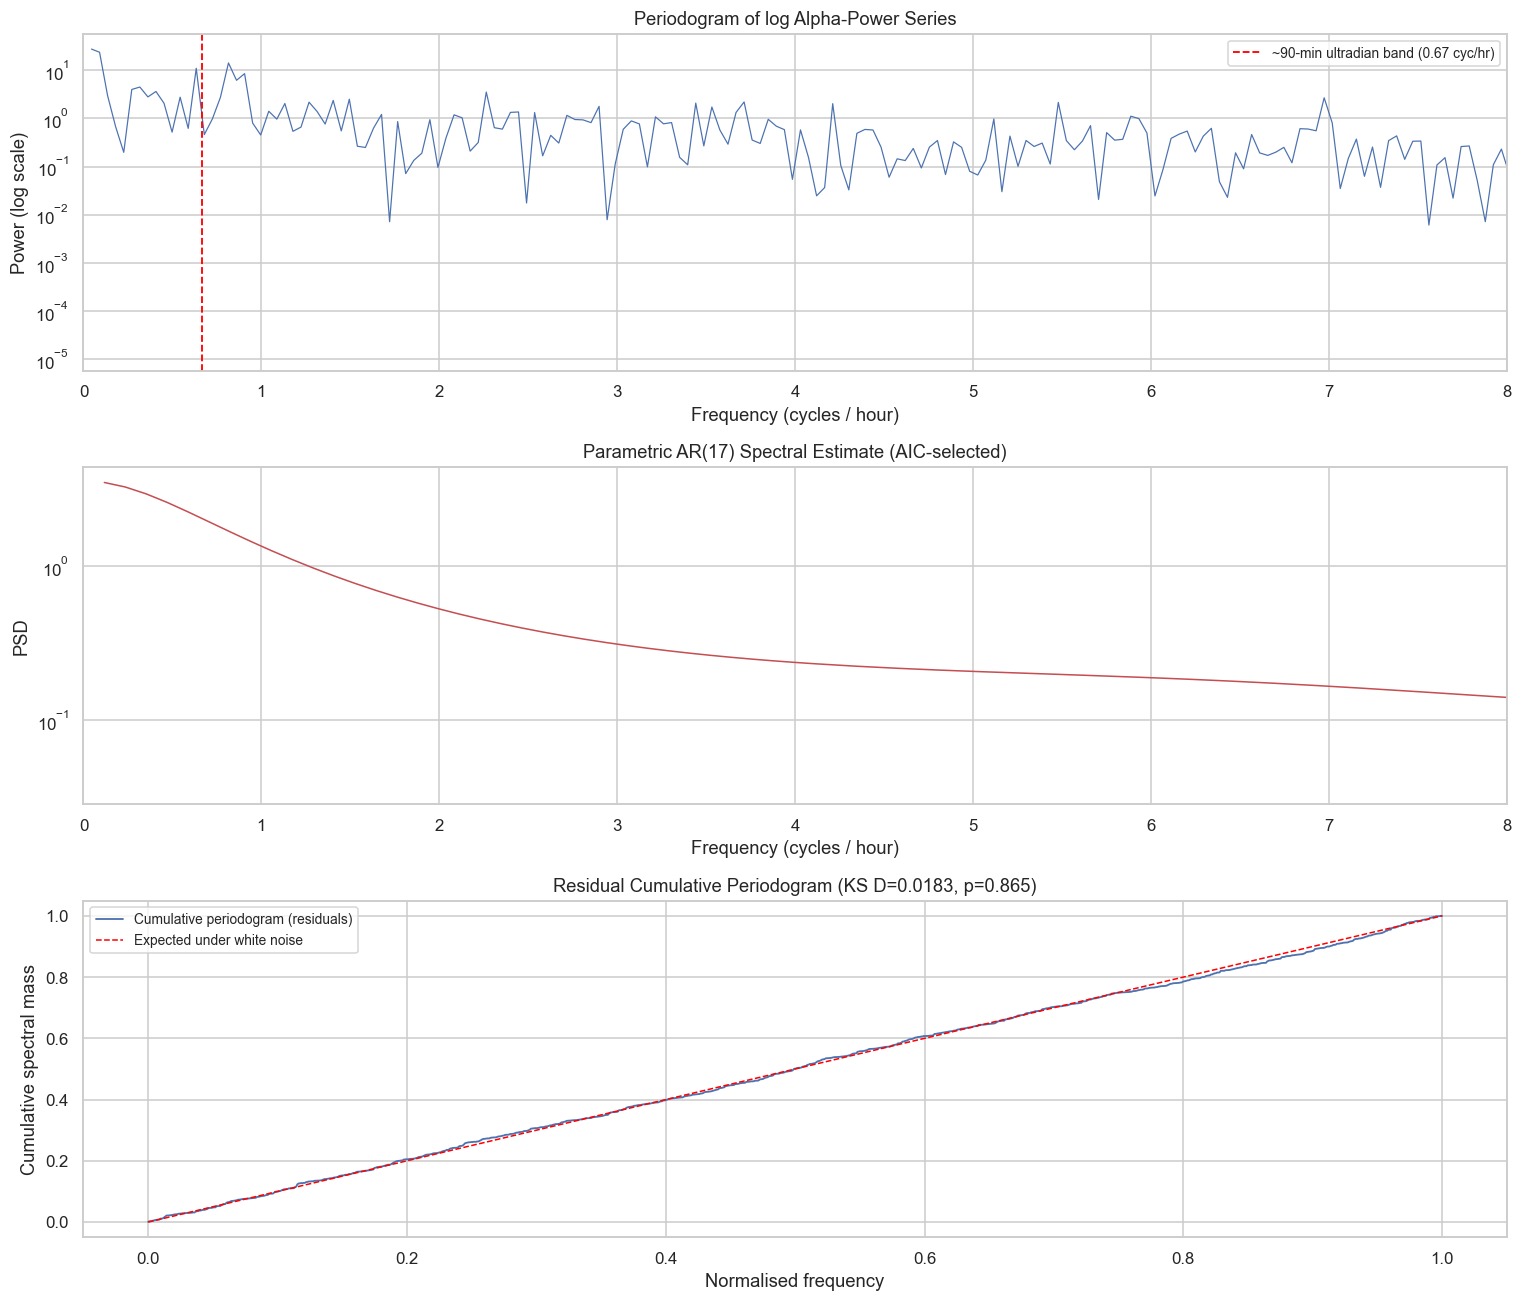

In [13]:
dt_hr = EPOCH_SEC/3600.0

# Periodogram of the (log) series -> where is the seasonality?
ser = log_transform(X_t).values
f_ep, Pxx = signal.periodogram(ser, fs=1.0)
f_hr, Pnz = f_ep[1:]/dt_hr, Pxx[1:]
g_ser, gp_ser = fisher_g_test(Pnz)
print(f'Series periodogram  : Fisher g={g_ser:.5f}  p={gp_ser:.3g}')
print('Top periodogram peaks:')
for i in np.argsort(Pnz)[-6:][::-1]:
    print(f'  {f_hr[i]:6.3f} cyc/hr  ~ {60/f_hr[i]:7.1f} min')

# Fisher + KS on the residuals -> are they white?
f_r, Pr = signal.periodogram(resid, fs=1.0); Pr = Pr[1:]
g_res, gp_res = fisher_g_test(Pr)
d_res, dp_res, cum = ks_cumulative_periodogram(Pr)
print(f'\nResidual Fisher g-test: g={g_res:.5f}  p={gp_res:.3g}  '
      f'-> {"periodicity remains" if gp_res<0.05 else "no leftover periodicity"}')
print(f'Residual KS test      : D={d_res:.4f}  p={dp_res:.3g}  '
      f'-> {"structure remains" if dp_res<0.05 else "consistent with white noise"}')

# Parametric AR PSD (AIC-selected order) for a smoother view of the peaks
ba, bo = np.inf, 1
for p in range(1, 26):
    try:
        mm = AutoReg(ser, lags=p, old_names=False).fit()
        if mm.aic < ba: ba, bo = mm.aic, p
    except Exception: pass
arf = AutoReg(ser, lags=bo, old_names=False).fit(); apar = arf.params[1:]; s2 = np.var(arf.resid)
w = np.linspace(0, np.pi, 512); H = np.ones(len(w), dtype=complex)
for k, a_k in enumerate(apar, start=1): H -= a_k*np.exp(-1j*w*k)
S_ar = s2/np.abs(H)**2; f_ar = (w/(2*np.pi))/dt_hr
print(f'\nParametric AR order (AIC) = {bo}')

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
axes[0].semilogy(f_hr, Pnz, color='#4C72B0', lw=0.8)
axes[0].axvline(1/1.5, color='red', lw=1.2, ls='--', label='~90-min ultradian band (0.67 cyc/hr)')
axes[0].set_title('Periodogram of log Alpha-Power Series'); axes[0].set_xlim(0, 8)
axes[0].set_xlabel('Frequency (cycles / hour)'); axes[0].set_ylabel('Power (log scale)'); axes[0].legend(fontsize=9)
axes[1].semilogy(f_ar[1:], S_ar[1:], color='#C44E52', lw=1.0); axes[1].set_xlim(0, 8)
axes[1].set_title(f'Parametric AR({bo}) Spectral Estimate (AIC-selected)')
axes[1].set_xlabel('Frequency (cycles / hour)'); axes[1].set_ylabel('PSD')
fp = np.linspace(0, 1, len(cum))
axes[2].plot(fp, cum, color='#4C72B0', lw=1.2, label='Cumulative periodogram (residuals)')
axes[2].plot(fp, fp, color='red', lw=1.0, ls='--', label='Expected under white noise')
axes[2].set_title(f'Residual Cumulative Periodogram (KS D={d_res:.4f}, p={dp_res:.3g})')
axes[2].set_xlabel('Normalised frequency'); axes[2].set_ylabel('Cumulative spectral mass'); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/spectral_analysis.png', bbox_inches='tight'); plt.show()

**Spectral findings.**

- **The series is strongly periodic.** Fisher's g-test on $X_t$ rejects white noise overwhelmingly
  ($p \approx 10^{-44}$). Beyond the record-length trend harmonics, the dominant peaks fall at **73.6, 94.6, 66.2 and
  69.7 minutes** — a *band* straddling the canonical ~90-minute NREM-REM ultradian cycle. This both confirms the
  sleep architecture and explains Section 6: the rhythm is smeared across periods, so no single seasonal lag $S$
  captures it, which is precisely why a hard SARIMA seasonal term failed.
- **The residuals are white.** Fisher's g-test on the ARIMA(2,1,2) residuals does *not* reject ($p \approx 0.23$),
  and the KS cumulative-periodogram test sits right on the white-noise diagonal ($D \approx 0.02$, $p \approx 0.87$).
  So the model has removed all the *linear/spectral* structure — consistent with the Ljung-Box result, and a useful
  cross-check from the frequency domain. (The only thing left is the nonlinear ARCH structure McLeod-Li found.)

## 12. Conclusion

My goal was to model and forecast overnight EEG alpha power with a fully manual, transparent time-series pipeline,
and to perform spectral analysis. I think the goals were met, with honest caveats.

- **Transformation & stationarity.** A log transform stabilised the multiplicative variance; one regular difference
  gave a stationary series. ADF supported this but I leaned on the ACF and EDA too.
- **Seasonality, re-examined.** The physiologically obvious $S=180$ seasonal model is *wrong* for this series:
  seasonal differencing over-differences, there is no seasonal ACF/PACF signature, and the cycle is spectrally
  broad. I therefore used a non-seasonal model and documented the rhythm spectrally.
- **Final model.** $\text{ARIMA}(2,1,2)$ on $\log(X_t)$, chosen by AICc (700.9) over four alternatives:
$$(1 - 1.134B + 0.187B^2)(1-B)\,Y_t = (1 - 1.730B + 0.731B^2)\,\varepsilon_t,\quad \hat\sigma^2 = 0.081.$$
  Residuals pass Ljung-Box and the spectral white-noise tests; they **fail** McLeod-Li, revealing an ARCH effect —
  the clearest direction for future work (an ARIMA+GARCH model).
- **Forecasting.** 1-step-ahead MAPE of 20.1%, beating persistence (23.2%) and naive-seasonal (31.2%) baselines.
- **Spectral analysis.** Periodogram localises the ~66–95 min ultradian band (Fisher $p\approx10^{-44}$); the
  residual Fisher and KS tests confirm the model leaves white noise behind.

**Acknowledgements.** Data from the PhysioNet Sleep-EDF Expanded Database. Thanks to the PSTAT W 274 instructor and
TAs for guidance on diagnostics, and to classmates for discussion of the over-differencing diagnosis.

### References
1. Kemp B. et al. (2000). A simple format for exchange of digitized polygraphic recordings. *Electroenceph. Clin. Neurophysiol.* 69(4), 391–395.
2. Goldberger A.L. et al. (2000). PhysioBank, PhysioToolkit, and PhysioNet. *Circulation* 101(23), e215–e220.
3. Box, Jenkins, Reinsel, Ljung (2015). *Time Series Analysis: Forecasting and Control*, 5th ed. Wiley.
4. Hurvich & Tsai (1989). Regression and time series model selection in small samples. *Biometrika* 76(2), 297–307.
5. McLeod & Li (1983). Diagnostic checking ARMA time series models using squared-residual autocorrelations. *J. Time Ser. Anal.* 4(4), 269–273.

In [14]:
print('=== RESULTS SUMMARY ===')
print(f'Series: {len(X_t)} epochs (~{len(X_t)*EPOCH_SEC/3600:.1f} h)   Train: {len(train)}  Test: {len(test)}')
print(f'Best model: {best["label"]}   AICc={best["aicc"]:.2f}')
print(f'ADF log(X): stat={adf_log["stat"]:.2f} p={adf_log["pval"]:.2g}  |  d1: stat={adf_diff["stat"]:.2f}')
print(f'1-step MAPE: {np.mean(np.abs((actual-pred_1step)/actual))*100:.2f}%')
print(f'Spectral: series Fisher p={gp_ser:.2g}  |  residual Fisher p={gp_res:.2g}  residual KS p={dp_res:.2g}')

=== RESULTS SUMMARY ===
Series: 2650 epochs (~22.1 h)   Train: 2120  Test: 530
Best model: ARIMA(2,1,2)   AICc=700.89
ADF log(X): stat=-7.69 p=1.4e-11  |  d1: stat=-16.92
1-step MAPE: 20.09%
Spectral: series Fisher p=1.4e-44  |  residual Fisher p=0.23  residual KS p=0.87
